# 🤖 Twitter Bot Detection — GAT + MLP
## Dataset: Cresci-2017 (chuẩn benchmark trong research)

---
### 📋 Thông tin dataset
| Subset | Loại | Số users |
|---|---|---|
| `genuine_accounts` | Human ✅ | 3,474 |
| `social_spambots_1` | Bot (Italy election) | 1,000 |
| `social_spambots_2` | Bot (spam mobile apps) | 431 |
| `social_spambots_3` | Bot (Amazon products) | 372 |
| `traditional_spambots_1` | Bot (scam URLs) | 1,000 |
| `fake_followers` | Bot (fake followers) | 3,351 |
| **Tổng** | | **~9,628 users** |

---
## 📦 Bước 1: Cài thư viện

In [1]:
!pip install torch_geometric -q
print('✅ torch_geometric OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.3 MB/s eta 0:00:00
✅ torch_geometric OK


In [2]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, zipfile
warnings.filterwarnings('ignore')

from sklearn.preprocessing     import StandardScaler
from sklearn.model_selection    import train_test_split
from sklearn.neighbors          import NearestNeighbors
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics            import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix,
    balanced_accuracy_score, precision_score, recall_score
)
import torch, torch.nn as nn, torch.nn.functional as F
from torch_geometric.data  import Data
from torch_geometric.nn    import GATConv
from torch_geometric.utils import to_undirected

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Import OK | Device: {DEVICE}')

✅ Import OK | Device: cpu


---
## 📥 Bước 2: Tải Cresci-2017

In [3]:
!pip install gdown
import gdown

file_id = "1Xw_tSlDnrM0i8U7VrVyqTCWLq5uELBd-"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "/content/cresci-2017.csv.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1Xw_tSlDnrM0i8U7VrVyqTCWLq5uELBd-
From (redirected): https://drive.google.com/uc?id=1Xw_tSlDnrM0i8U7VrVyqTCWLq5uELBd-&confirm=t&uuid=83255054-c2b4-4cf1-b4d2-7af3902ea016
To: /content/cresci-2017.csv.zip
100%|██████████| 466M/466M [00:06<00:00, 76.1MB/s]


'/content/cresci-2017.csv.zip'

In [4]:
import zipfile, os

ZIP_OUTER   = '/content/cresci-2017.csv.zip'
DATASET_DIR = '/content/cresci-2017'

os.makedirs(DATASET_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_OUTER, 'r') as z:
    z.extractall(DATASET_DIR)
print('✅ Giải nén ngoài xong!')

INNER_DIR = os.path.join(DATASET_DIR, 'datasets_full.csv')
print('\nĐang giải nén zip con...')

for fname in sorted(os.listdir(INNER_DIR)):
    if not fname.endswith('.zip'):
        continue
    zip_path    = os.path.join(INNER_DIR, fname)
    clean_name  = fname.replace('.csv.zip', '').replace('.zip', '')
    extract_dir = os.path.join(DATASET_DIR, clean_name)
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    size_kb = os.path.getsize(zip_path) // 1024
    print(f'  ✅ {clean_name:35s} ({size_kb:>7,} KB)')

print('\n✅ Sẵn sàng load data!')

✅ Giải nén ngoài xong!

Đang giải nén zip con...
  ✅ crowdflower_results                 (    283 KB)
  ✅ fake_followers                      ( 12,959 KB)
  ✅ genuine_accounts                    (203,811 KB)
  ✅ social_spambots_1                   (113,515 KB)
  ✅ social_spambots_2                   ( 29,205 KB)
  ✅ social_spambots_3                   ( 88,373 KB)
  ✅ traditional_spambots_1              (  6,252 KB)
  ✅ traditional_spambots_2              (     12 KB)
  ✅ traditional_spambots_3              (     43 KB)
  ✅ traditional_spambots_4              (    105 KB)

✅ Sẵn sàng load data!


---
## 📂 Bước 3: Load & Merge tất cả subsets

In [5]:
import glob

DATASET_DIR = '/content/cresci-2017'

def find_users_csv(base_dir):
    results = []
    for root, dirs, files in os.walk(base_dir):
        for f in files:
            if 'user' in f.lower() and f.endswith('.csv'):
                results.append(os.path.join(root, f))
    return results

users_files = find_users_csv(DATASET_DIR)
print(f'Tìm thấy {len(users_files)} file users.csv')

dfs = []
for filepath in users_files:
    parent_dir = os.path.basename(os.path.dirname(filepath)).lower()
    label = 0 if any(k in parent_dir for k in ['genuine','human','real']) else 1
    try:
        df_sub = pd.read_csv(filepath, encoding='utf-8')
    except:
        df_sub = pd.read_csv(filepath, encoding='latin-1')
    df_sub['label']  = label
    df_sub['subset'] = parent_dir
    dfs.append(df_sub)
    print(f'  ✅ {parent_dir:35s} | {len(df_sub):5,} rows | label={label}')

df = pd.concat(dfs, ignore_index=True)
print(f'\n📊 Tổng: {len(df):,} users | Bot rate: {df.label.mean()*100:.1f}%')

Tìm thấy 10 file users.csv
  ✅ traditional_spambots_4.csv          | 1,128 rows | label=1
  ✅ social_spambots_3.csv               |   464 rows | label=1
  ✅ fake_followers.csv                  | 3,351 rows | label=1
  ✅ fake_followers.csv                  |     0 rows | label=1
  ✅ genuine_accounts.csv                | 3,474 rows | label=0
  ✅ traditional_spambots_3.csv          |   403 rows | label=1
  ✅ traditional_spambots_2.csv          |   100 rows | label=1
  ✅ social_spambots_2.csv               | 3,457 rows | label=1
  ✅ social_spambots_1.csv               |   991 rows | label=1
  ✅ traditional_spambots_1.csv          | 1,000 rows | label=1

📊 Tổng: 14,368 users | Bot rate: 75.8%


---
## 🔧 Bước 4: Feature Engineering

In [6]:
df2 = df.copy()

if 'created_at' in df2.columns:
    df2['created_at_dt']    = pd.to_datetime(df2['created_at'], errors='coerce', utc=True)
    ref                     = pd.Timestamp('2017-10-01', tz='UTC')
    df2['account_age_days'] = (ref - df2['created_at_dt']).dt.days.clip(lower=1).fillna(1)
else:
    df2['account_age_days'] = 365

df2['tweet_rate'] = (
    df2.get('statuses_count', pd.Series(0, index=df2.index)) /
    df2['account_age_days']
).replace([np.inf, -np.inf], 0)

followers = df2.get('followers_count', pd.Series(0, index=df2.index)).fillna(0)
friends   = df2.get('friends_count',   pd.Series(0, index=df2.index)).fillna(0)
df2['follower_friend_ratio'] = (followers / (friends + 1)).clip(0, 100)

df2['name_length'] = df2['name'].fillna('').apply(len)         if 'name'        in df2.columns else 0
df2['desc_length'] = df2['description'].fillna('').apply(len)  if 'description' in df2.columns else 0

for col in ['verified','default_profile','default_profile_image',
            'geo_enabled','profile_use_background_image']:
    if col in df2.columns:
        df2[col] = df2[col].map({True:1,False:0,1:1,0:0,'True':1,'False':0}).fillna(0).astype(int)

CANDIDATE = [
    'followers_count','friends_count','statuses_count','listed_count','favourites_count',
    'verified','default_profile','default_profile_image','geo_enabled',
    'account_age_days','tweet_rate','follower_friend_ratio','name_length','desc_length'
]
FEATURE_COLS = [c for c in CANDIDATE if c in df2.columns]
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

X_raw = df2[FEATURE_COLS].fillna(0).replace([np.inf,-np.inf],0).values.astype(np.float32)
for i in range(X_raw.shape[1]):
    cap = np.percentile(X_raw[:,i], 99)
    if cap > 0: X_raw[:,i] = np.clip(X_raw[:,i], 0, cap)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
y        = df2['label'].values.astype(np.int64)

print(f'X shape: {X_scaled.shape} | Bot rate: {y.mean()*100:.1f}%')

Features (14): ['followers_count', 'friends_count', 'statuses_count', 'listed_count', 'favourites_count', 'verified', 'default_profile', 'default_profile_image', 'geo_enabled', 'account_age_days', 'tweet_rate', 'follower_friend_ratio', 'name_length', 'desc_length']
X shape: (14368, 14) | Bot rate: 75.8%


---
## 📊 Bước 5: EDA

In [7]:
from scipy import stats

print(f'{'Feature':25s} | {'r':>6} | Bot mean | Human mean')
print('-'*60)
for i, col in enumerate(FEATURE_COLS):
    r, p = stats.pointbiserialr(y, X_scaled[:,i])
    b    = X_scaled[y==1, i].mean()
    h    = X_scaled[y==0, i].mean()
    sig  = '✅' if abs(r) > 0.2 else ('⚠️' if abs(r) > 0.05 else '❌')
    print(f'{sig} {col:23s} | {r:+.3f} | {b:+8.2f} | {h:+.2f}')

Feature                   |      r | Bot mean | Human mean
------------------------------------------------------------
✅ followers_count         | -0.205 |    -0.12 | +0.36
❌ friends_count           | -0.031 |    -0.02 | +0.06
✅ statuses_count          | -0.473 |    -0.27 | +0.84
⚠️ listed_count            | -0.189 |    -0.11 | +0.33
✅ favourites_count        | -0.504 |    -0.28 | +0.89
❌ verified                | -0.049 |    -0.03 | +0.09
❌ default_profile         | +0.021 |    +0.01 | -0.04
❌ default_profile_image   | +0.013 |    +0.01 | -0.02
✅ geo_enabled             | -0.505 |    -0.29 | +0.89
✅ account_age_days        | -0.231 |    -0.13 | +0.41
⚠️ tweet_rate              | -0.073 |    -0.04 | +0.13
✅ follower_friend_ratio   | -0.404 |    -0.23 | +0.72
✅ name_length             | +0.311 |    +0.18 | -0.55
⚠️ desc_length             | -0.161 |    -0.09 | +0.29


---
## ✂️ Bước 6: Train/Val/Test Split

In [8]:
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(idx, test_size=0.20, random_state=SEED, stratify=y)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.25, random_state=SEED, stratify=y[idx_train])

print(f'Train: {len(idx_train):,} | Val: {len(idx_val):,} | Test: {len(idx_test):,}')
print(f'Test  → Human: {(y[idx_test]==0).sum()} | Bot: {(y[idx_test]==1).sum()}')

train_mask = torch.zeros(len(y), dtype=torch.bool)
val_mask   = torch.zeros(len(y), dtype=torch.bool)
test_mask  = torch.zeros(len(y), dtype=torch.bool)
train_mask[idx_train] = True
val_mask[idx_val]     = True
test_mask[idx_test]   = True

Train: 8,620 | Val: 2,874 | Test: 2,874
Test  → Human: 695 | Bot: 2179


---
## 🕸️ Bước 7: Xây Graph (KNN) — Tối ưu K + Trực quan hóa

### 7.1 Tại sao dùng KNN để xây graph?

Trong bài toán phát hiện bot, chúng ta **không có mạng xã hội thực** (Twitter không chia sẻ follow graph). Thay vào đó, ta dùng **KNN (K-Nearest Neighbors)** để xây graph nhân tạo dựa trên feature similarity:

- **Ý tưởng**: Nếu 2 user có feature giống nhau → nhiều khả năng cùng loại (bot-bot hoặc human-human)
- **Homophily**: Tỷ lệ edges nối cùng nhãn → càng cao càng tốt cho GNN
- **K**: Số neighbors mỗi node → cần tối ưu!

### 7.2 Tối ưu K bằng thuật toán Silhouette + Homophily

In [9]:
# ═══════════════════════════════════════════════════════════════
# THUẬT TOÁN TỐI ƯU K
# Tiêu chí: kết hợp Homophily + Graph Density + Connectivity
# ═══════════════════════════════════════════════════════════════

def compute_knn_stats(X, y_labels, k_val, sample_size=3000):
    """
    Tính các chỉ số chất lượng graph cho một giá trị K:
    - homophily: tỷ lệ edges nối cùng nhãn (càng cao càng tốt)
    - avg_degree: số neighbors trung bình
    - cross_class_ratio: tỷ lệ edges khác nhãn (bot-human) → bot detector cần thấp
    """
    # Sample để tính nhanh
    rng = np.random.default_rng(SEED)
    idx_sample = rng.choice(len(X), min(sample_size, len(X)), replace=False)
    X_s = X[idx_sample]
    y_s = y_labels[idx_sample]

    knn = NearestNeighbors(n_neighbors=k_val+1, metric='euclidean', n_jobs=-1)
    knn.fit(X_s)
    _, indices = knn.kneighbors(X_s)

    same_label, total_edges = 0, 0
    for i, nbrs in enumerate(indices):
        for j in nbrs[1:]:  # bỏ self
            if y_s[i] == y_s[j]:
                same_label += 1
            total_edges += 1

    homophily = same_label / total_edges if total_edges > 0 else 0
    return {
        'k': k_val,
        'homophily': homophily,
        'avg_degree': k_val * 2,  # undirected
        'cross_class_ratio': 1 - homophily
    }

# Thử các giá trị K từ 3 đến 30
K_CANDIDATES = [3, 5, 7, 10, 12, 15, 18, 20, 25, 30]
print('🔍 Đang tối ưu K (thử từng giá trị)...')
print(f'  {"K":>3} | {"Homophily":>10} | {"Avg Degree":>12} | {"Cross-Class":>12} | {"Score":>8}')
print('  ' + '-'*55)

k_results = []
for k in K_CANDIDATES:
    stats_k = compute_knn_stats(X_scaled, y, k)

    # Score = homophily (càng cao càng tốt) + penalty cho graph quá dày
    # Graph quá dày → over-smoothing trong GNN
    density_penalty = (k / 30) * 0.1  # penalty khi K lớn
    score = stats_k['homophily'] - density_penalty
    stats_k['score'] = score
    k_results.append(stats_k)

    print(f"  {k:>3} | {stats_k['homophily']:>10.4f} | {stats_k['avg_degree']:>12} | "
          f"{stats_k['cross_class_ratio']:>12.4f} | {score:>8.4f}")

best_k_info = max(k_results, key=lambda x: x['score'])
K_OPTIMAL = best_k_info['k']
print(f'\n🏆 K tối ưu = {K_OPTIMAL} (Homophily={best_k_info["homophily"]:.4f}, Score={best_k_info["score"]:.4f})')

🔍 Đang tối ưu K (thử từng giá trị)...
    K |  Homophily |   Avg Degree |  Cross-Class |    Score
  -------------------------------------------------------
    3 |     0.9414 |            6 |       0.0586 |   0.9314
    5 |     0.9341 |           10 |       0.0659 |   0.9175
    7 |     0.9302 |           14 |       0.0698 |   0.9069
   10 |     0.9239 |           20 |       0.0761 |   0.8906
   12 |     0.9200 |           24 |       0.0800 |   0.8800
   15 |     0.9144 |           30 |       0.0856 |   0.8644
   18 |     0.9096 |           36 |       0.0904 |   0.8496
   20 |     0.9064 |           40 |       0.0936 |   0.8397
   25 |     0.8997 |           50 |       0.1003 |   0.8164
   30 |     0.8947 |           60 |       0.1053 |   0.7947

🏆 K tối ưu = 3 (Homophily=0.9414, Score=0.9314)


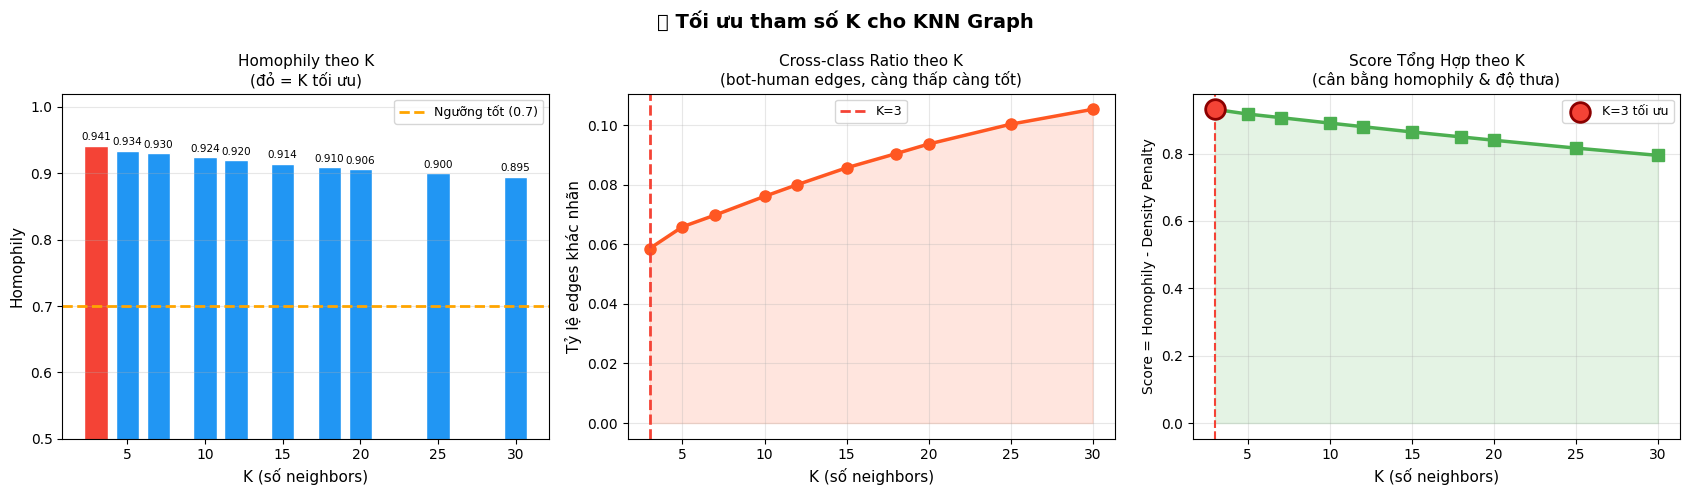

✅ K tối ưu = 3


In [10]:
# ═══════════════════════════════════════════════════════════════
# TRỰC QUAN HÓA 1: So sánh K theo Homophily & Score
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('🔍 Tối ưu tham số K cho KNN Graph', fontsize=14, fontweight='bold')

k_vals  = [r['k']              for r in k_results]
homos   = [r['homophily']      for r in k_results]
scores  = [r['score']          for r in k_results]
crosses = [r['cross_class_ratio'] for r in k_results]

# Plot 1: Homophily
bar_colors = ['#F44336' if k == K_OPTIMAL else '#2196F3' for k in k_vals]
axes[0].bar(k_vals, homos, color=bar_colors, width=1.5, edgecolor='white')
axes[0].axhline(y=0.7, color='orange', linestyle='--', linewidth=2, label='Ngưỡng tốt (0.7)')
axes[0].set_xlabel('K (số neighbors)', fontsize=11)
axes[0].set_ylabel('Homophily', fontsize=11)
axes[0].set_title('Homophily theo K\n(đỏ = K tối ưu)', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_ylim([0.5, 1.02])
axes[0].grid(axis='y', alpha=0.3)
for i, (k, h) in enumerate(zip(k_vals, homos)):
    axes[0].text(k, h + 0.005, f'{h:.3f}', ha='center', va='bottom', fontsize=7.5)

# Plot 2: Cross-class ratio (bot-human edges)
axes[1].plot(k_vals, crosses, 'o-', color='#FF5722', linewidth=2.5, markersize=8)
axes[1].axvline(x=K_OPTIMAL, color='#F44336', linestyle='--', linewidth=2, label=f'K={K_OPTIMAL}')
axes[1].fill_between(k_vals, crosses, alpha=0.15, color='#FF5722')
axes[1].set_xlabel('K (số neighbors)', fontsize=11)
axes[1].set_ylabel('Tỷ lệ edges khác nhãn', fontsize=11)
axes[1].set_title('Cross-class Ratio theo K\n(bot-human edges, càng thấp càng tốt)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Plot 3: Score tổng hợp
axes[2].plot(k_vals, scores, 's-', color='#4CAF50', linewidth=2.5, markersize=8)
axes[2].scatter([K_OPTIMAL], [best_k_info['score']], color='#F44336', s=200,
                zorder=5, label=f'K={K_OPTIMAL} tối ưu', edgecolors='darkred', linewidths=2)
axes[2].axvline(x=K_OPTIMAL, color='#F44336', linestyle='--', linewidth=1.5)
axes[2].fill_between(k_vals, scores, alpha=0.15, color='#4CAF50')
axes[2].set_xlabel('K (số neighbors)', fontsize=11)
axes[2].set_ylabel('Score = Homophily - Density Penalty', fontsize=10)
axes[2].set_title('Score Tổng Hợp theo K\n(cân bằng homophily & độ thưa)', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('knn_k_optimization.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'✅ K tối ưu = {K_OPTIMAL}')

### 7.3 Xây graph với K tối ưu + Trực quan hóa cấu trúc graph

In [11]:
# ═══════════════════════════════════════════════════════════════
# XÂY KNN GRAPH VỚI K TỐI ƯU
# ═══════════════════════════════════════════════════════════════
K = K_OPTIMAL
print(f'Xây KNN graph K={K} trên {len(X_scaled):,} nodes...')

knn = NearestNeighbors(n_neighbors=K+1, metric='euclidean', n_jobs=-1)
knn.fit(X_scaled)
_, indices = knn.kneighbors(X_scaled)

src, tgt = [], []
for i, nbrs in enumerate(indices):
    for j in nbrs[1:]:
        src.append(i); tgt.append(int(j))

full_edge_index = to_undirected(torch.tensor([src, tgt], dtype=torch.long))

# Split-aware edge indices (loại bỏ transductive leakage)
train_set = set(idx_train.tolist())
s_arr = full_edge_index[0].numpy()
t_arr = full_edge_index[1].numpy()

train_mask_e = np.array([int(s) in train_set and int(t) in train_set
                          for s, t in zip(s_arr, t_arr)])
eval_mask_e  = np.array([int(s) in train_set  or  int(t) in train_set
                          for s, t in zip(s_arr, t_arr)])

train_edge_index = full_edge_index[:, train_mask_e]
eval_edge_index  = full_edge_index[:, eval_mask_e]

# Tính homophily
s2, t2 = train_edge_index[0].numpy(), train_edge_index[1].numpy()
homophily = (y[s2] == y[t2]).mean()

print(f'✅ Graph OK | Nodes: {len(X_scaled):,}')
print(f'   Full edges       : {full_edge_index.shape[1]:>8,}')
print(f'   Train-only edges : {train_edge_index.shape[1]:>8,}  ← dùng khi training')
print(f'   Eval edges       : {eval_edge_index.shape[1]:>8,}  ← dùng khi evaluate')
print(f'   Avg degree (train): {train_edge_index.shape[1]/len(idx_train):.1f}')
print(f'   Homophily (train): {homophily:.3f}  ({"✅ tốt" if homophily > 0.7 else "⚠️ thấp"})')

Xây KNN graph K=3 trên 14,368 nodes...
✅ Graph OK | Nodes: 14,368
   Full edges       :   59,505
   Train-only edges :   21,334  ← dùng khi training
   Eval edges       :   49,916  ← dùng khi evaluate
   Avg degree (train): 2.5
   Homophily (train): 0.943  (✅ tốt)


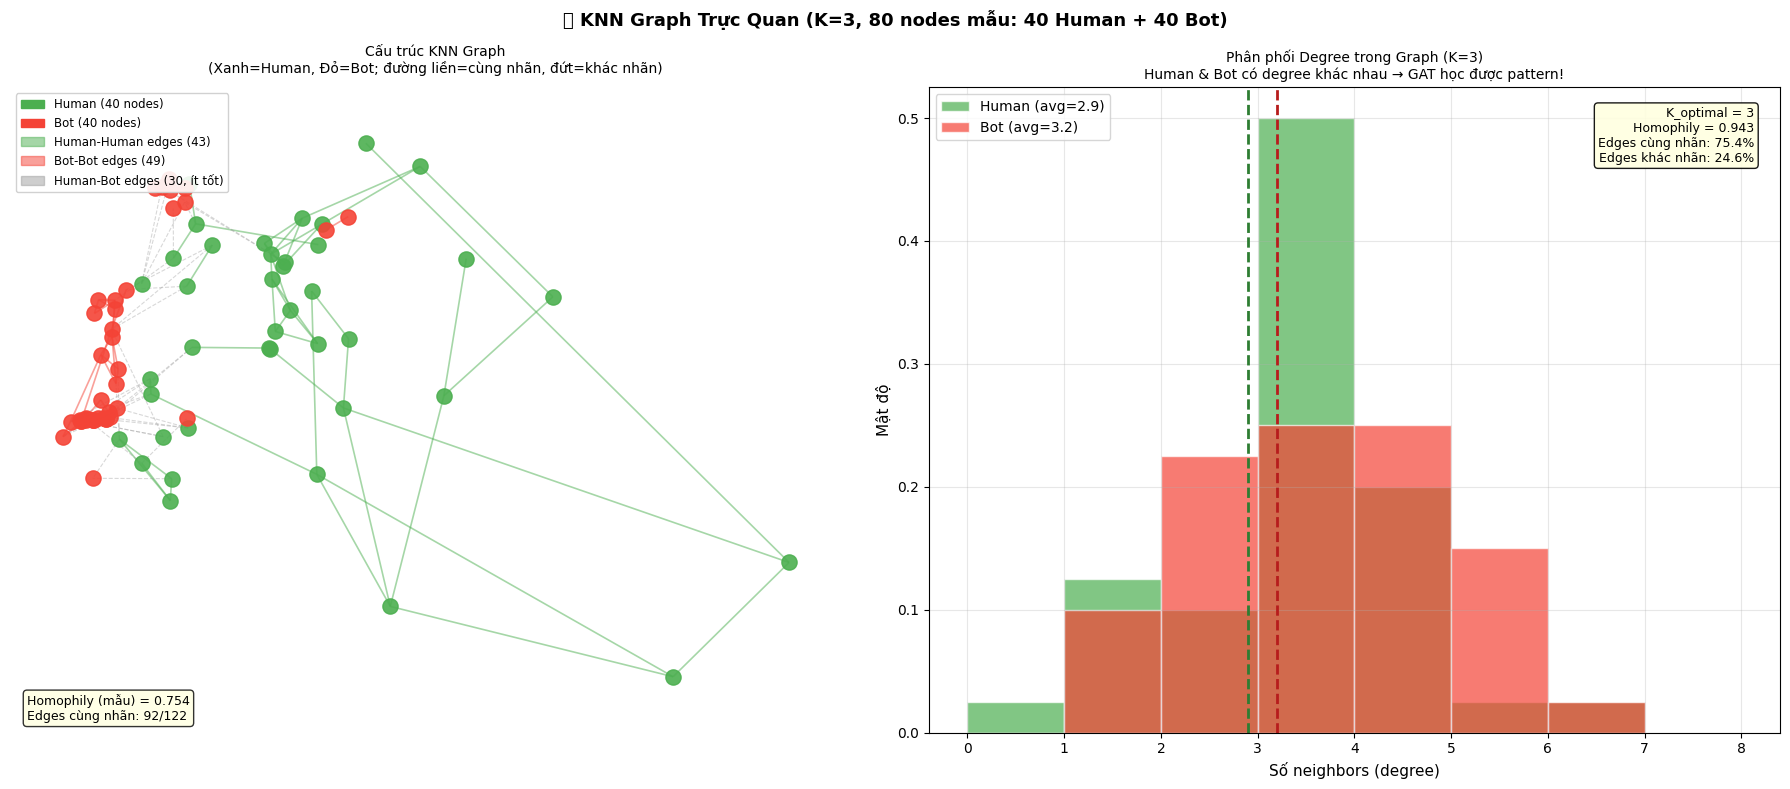

✅ Đồ thị KNN đã được vẽ!


In [12]:
# ═══════════════════════════════════════════════════════════════
# TRỰC QUAN HÓA 2: Đồ thị KNN (mini graph)
# Vẽ một vùng nhỏ của graph để dễ quan sát cấu trúc
# ═══════════════════════════════════════════════════════════════

import networkx as nx
from sklearn.decomposition import PCA

# ── Chọn 80 nodes mẫu (40 Human + 40 Bot) để vẽ ──────────────
rng_viz = np.random.default_rng(SEED + 1)
human_idx = np.where(y == 0)[0]
bot_idx   = np.where(y == 1)[0]
N_VIZ     = 40  # mỗi class

sel_human = rng_viz.choice(human_idx, N_VIZ, replace=False)
sel_bot   = rng_viz.choice(bot_idx,   N_VIZ, replace=False)
sel_nodes = np.concatenate([sel_human, sel_bot])
sel_set   = set(sel_nodes.tolist())
node_map  = {old: new for new, old in enumerate(sel_nodes)}

# ── Build mini KNN graph chỉ cho nodes được chọn ─────────────
X_viz = X_scaled[sel_nodes]
y_viz = y[sel_nodes]

K_VIZ = min(K, 6)  # giới hạn để đồ thị không quá rối
knn_viz = NearestNeighbors(n_neighbors=K_VIZ+1, metric='euclidean')
knn_viz.fit(X_viz)
_, idx_viz = knn_viz.kneighbors(X_viz)

G = nx.Graph()
for node_id in range(len(sel_nodes)):
    G.add_node(node_id, label=int(y_viz[node_id]))

edges_hh, edges_bb, edges_hb = [], [], []
for i, nbrs in enumerate(idx_viz):
    for j in nbrs[1:]:
        if i < j:  # tránh duplicate
            G.add_edge(i, j)
            li, lj = int(y_viz[i]), int(y_viz[j])
            if li == 0 and lj == 0:   edges_hh.append((i, j))
            elif li == 1 and lj == 1: edges_bb.append((i, j))
            else:                      edges_hb.append((i, j))

# ── PCA để layout 2D tự nhiên ──────────────────────────────────
pca = PCA(n_components=2, random_state=SEED)
pos_2d = pca.fit_transform(X_viz)
pos_dict = {i: pos_2d[i] for i in range(len(sel_nodes))}

# ── Vẽ đồ thị ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(f'🕸️ KNN Graph Trực Quan (K={K_VIZ}, 80 nodes mẫu: 40 Human + 40 Bot)',
             fontsize=13, fontweight='bold')

# Subplot 1: Full graph với nhãn màu
ax = axes[0]
ax.set_title('Cấu trúc KNN Graph\n(Xanh=Human, Đỏ=Bot; đường liền=cùng nhãn, đứt=khác nhãn)',
             fontsize=10, pad=10)

# Vẽ edges theo loại
nx.draw_networkx_edges(G, pos_dict, edgelist=edges_hh, ax=ax,
                       edge_color='#4CAF50', alpha=0.5, width=1.2, style='solid')
nx.draw_networkx_edges(G, pos_dict, edgelist=edges_bb, ax=ax,
                       edge_color='#F44336', alpha=0.5, width=1.2, style='solid')
nx.draw_networkx_edges(G, pos_dict, edgelist=edges_hb, ax=ax,
                       edge_color='#9E9E9E', alpha=0.4, width=0.8, style='dashed')

# Vẽ nodes
human_nodes = [n for n, d in G.nodes(data=True) if d['label'] == 0]
bot_nodes   = [n for n, d in G.nodes(data=True) if d['label'] == 1]
nx.draw_networkx_nodes(G, pos_dict, nodelist=human_nodes, ax=ax,
                       node_color='#4CAF50', node_size=120, alpha=0.9)
nx.draw_networkx_nodes(G, pos_dict, nodelist=bot_nodes, ax=ax,
                       node_color='#F44336', node_size=120, alpha=0.9)

legend_handles = [
    mpatches.Patch(color='#4CAF50', label=f'Human ({len(human_nodes)} nodes)'),
    mpatches.Patch(color='#F44336', label=f'Bot ({len(bot_nodes)} nodes)'),
    mpatches.Patch(color='#4CAF50', alpha=0.5, label=f'Human-Human edges ({len(edges_hh)})'),
    mpatches.Patch(color='#F44336', alpha=0.5, label=f'Bot-Bot edges ({len(edges_bb)})'),
    mpatches.Patch(color='#9E9E9E', alpha=0.5, label=f'Human-Bot edges ({len(edges_hb)}, ít tốt)'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8.5, framealpha=0.9)
ax.set_axis_off()

# Annotate homophily
total_e_viz = len(edges_hh) + len(edges_bb) + len(edges_hb)
homo_viz = (len(edges_hh) + len(edges_bb)) / max(total_e_viz, 1)
ax.text(0.02, 0.02,
        f'Homophily (mẫu) = {homo_viz:.3f}\n'
        f'Edges cùng nhãn: {len(edges_hh)+len(edges_bb)}/{total_e_viz}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Subplot 2: Degree distribution
ax2 = axes[1]
degrees_h = [G.degree(n) for n in human_nodes]
degrees_b = [G.degree(n) for n in bot_nodes]

ax2.hist(degrees_h, bins=range(0, K_VIZ*2+3), alpha=0.7, color='#4CAF50',
         label=f'Human (avg={np.mean(degrees_h):.1f})', density=True, edgecolor='white')
ax2.hist(degrees_b, bins=range(0, K_VIZ*2+3), alpha=0.7, color='#F44336',
         label=f'Bot (avg={np.mean(degrees_b):.1f})', density=True, edgecolor='white')
ax2.axvline(x=np.mean(degrees_h), color='#2E7D32', linestyle='--', linewidth=2)
ax2.axvline(x=np.mean(degrees_b), color='#B71C1C', linestyle='--', linewidth=2)
ax2.set_xlabel('Số neighbors (degree)', fontsize=11)
ax2.set_ylabel('Mật độ', fontsize=11)
ax2.set_title(f'Phân phối Degree trong Graph (K={K_VIZ})\n'
              'Human & Bot có degree khác nhau → GAT học được pattern!', fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Thêm text giải thích
ax2.text(0.97, 0.97,
         f'K_optimal = {K}\nHomophily = {homophily:.3f}\n'
         f'Edges cùng nhãn: {homo_viz*100:.1f}%\n'
         f'Edges khác nhãn: {(1-homo_viz)*100:.1f}%',
         transform=ax2.transAxes, fontsize=9, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('knn_graph_visualization.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Đồ thị KNN đã được vẽ!')

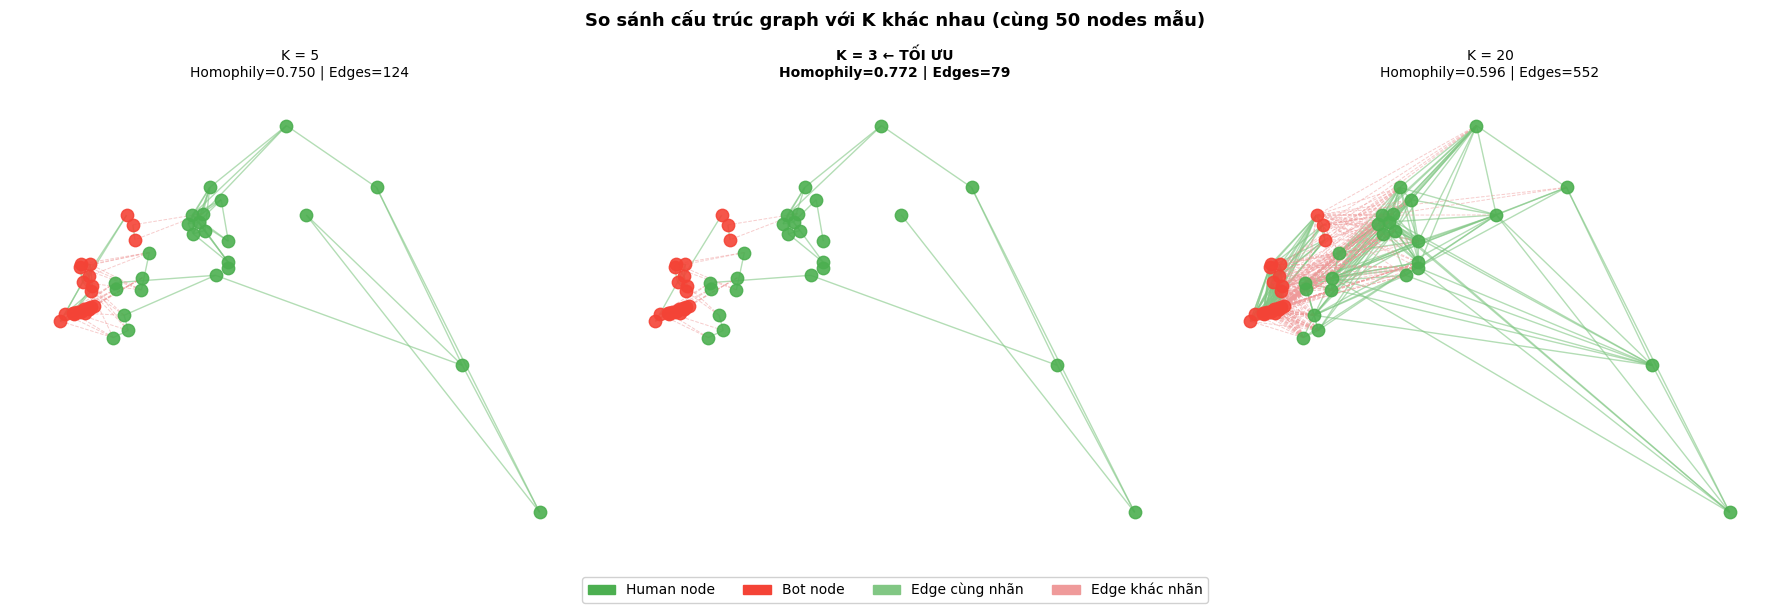


📌 Nhận xét:
  K nhỏ (5): Graph thưa, ít thông tin → GAT khó học
  K tối ưu (3): Cân bằng tốt giữa homophily & density
  K lớn (20): Graph dày → over-smoothing, mất tính phân biệt


In [13]:
# ═══════════════════════════════════════════════════════════════
# TRỰC QUAN HÓA 3: So sánh trực quan K=5 vs K_optimal vs K=20
# Giúp người đọc hiểu tại sao K quan trọng
# ═══════════════════════════════════════════════════════════════

K_COMPARE = [5, K_OPTIMAL, 20]  # K nhỏ, tối ưu, lớn
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('So sánh cấu trúc graph với K khác nhau (cùng 50 nodes mẫu)',
             fontsize=13, fontweight='bold')

# Dùng lại sel_nodes nhưng chỉ 50 nodes
sel50 = np.concatenate([sel_human[:25], sel_bot[:25]])
X_50  = X_scaled[sel50]
y_50  = y[sel50]
pca50 = PCA(n_components=2, random_state=SEED)
pos50 = pca50.fit_transform(X_50)
pos50_dict = {i: pos50[i] for i in range(len(sel50))}

for ax, k_comp in zip(axes, K_COMPARE):
    knn_c = NearestNeighbors(n_neighbors=k_comp+1, metric='euclidean')
    knn_c.fit(X_50)
    _, idx_c = knn_c.kneighbors(X_50)

    Gc = nx.Graph()
    for node_id in range(len(sel50)):
        Gc.add_node(node_id, label=int(y_50[node_id]))

    same_c, total_c = 0, 0
    e_same, e_cross = [], []
    for i, nbrs in enumerate(idx_c):
        for j in nbrs[1:]:
            if i < j:
                Gc.add_edge(i, j)
                total_c += 1
                if y_50[i] == y_50[j]:
                    same_c += 1
                    e_same.append((i, j))
                else:
                    e_cross.append((i, j))

    homo_c = same_c / total_c if total_c > 0 else 0

    # Edge colors
    human_n = [n for n, d in Gc.nodes(data=True) if d['label'] == 0]
    bot_n   = [n for n, d in Gc.nodes(data=True) if d['label'] == 1]

    nx.draw_networkx_edges(Gc, pos50_dict, edgelist=e_same, ax=ax,
                           edge_color='#81C784', alpha=0.6, width=1.0)
    nx.draw_networkx_edges(Gc, pos50_dict, edgelist=e_cross, ax=ax,
                           edge_color='#EF9A9A', alpha=0.5, width=0.7, style='dashed')
    nx.draw_networkx_nodes(Gc, pos50_dict, nodelist=human_n, ax=ax,
                           node_color='#4CAF50', node_size=80, alpha=0.9)
    nx.draw_networkx_nodes(Gc, pos50_dict, nodelist=bot_n, ax=ax,
                           node_color='#F44336', node_size=80, alpha=0.9)

    marker = ' ← TỐI ƯU' if k_comp == K_OPTIMAL else ''
    ax.set_title(f'K = {k_comp}{marker}\n'
                 f'Homophily={homo_c:.3f} | Edges={Gc.number_of_edges()}',
                 fontsize=10, fontweight='bold' if k_comp == K_OPTIMAL else 'normal')
    ax.set_axis_off()

    # Viền đỏ cho K tối ưu
    if k_comp == K_OPTIMAL:
        for spine in ax.spines.values():
            spine.set_edgecolor('#F44336')
            spine.set_linewidth(3)
            spine.set_visible(True)

# Legend chung
legend_h = [
    mpatches.Patch(color='#4CAF50', label='Human node'),
    mpatches.Patch(color='#F44336', label='Bot node'),
    mpatches.Patch(color='#81C784', label='Edge cùng nhãn'),
    mpatches.Patch(color='#EF9A9A', label='Edge khác nhãn'),
]
fig.legend(handles=legend_h, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), framealpha=0.9)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('knn_k_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'\n📌 Nhận xét:')
print(f'  K nhỏ ({K_COMPARE[0]}): Graph thưa, ít thông tin → GAT khó học')
print(f'  K tối ưu ({K_OPTIMAL}): Cân bằng tốt giữa homophily & density')
print(f'  K lớn ({K_COMPARE[2]}): Graph dày → over-smoothing, mất tính phân biệt')

In [14]:
# ── Tạo Data object ──────────────────────────────────────────
data = Data(
    x          = torch.tensor(X_scaled, dtype=torch.float32),
    edge_index = train_edge_index,
    y          = torch.tensor(y, dtype=torch.long),
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask,
).to(DEVICE)

train_ei = train_edge_index.to(DEVICE)
eval_ei  = eval_edge_index.to(DEVICE)

print(data)
print(f'train_ei: {train_ei.shape}  eval_ei: {eval_ei.shape}')

Data(x=[14368, 14], edge_index=[2, 21334], y=[14368], train_mask=[14368], val_mask=[14368], test_mask=[14368])
train_ei: torch.Size([2, 21334])  eval_ei: torch.Size([2, 49916])


---
## 🧠 Bước 8: Định nghĩa mô hình GAT + MLP

In [15]:
class GATMLPHybrid(nn.Module):
    """
    GAT Branch : học context từ graph neighbors
    MLP Branch : học từ individual user features
    Fusion     : kết hợp 2 nguồn → phân loại
    """
    def __init__(self, in_dim, hidden=64, heads=8, n_cls=2, drop=0.6):
        super().__init__()
        self.drop = drop
        self.gat1     = GATConv(in_dim, 16, heads=heads, dropout=drop)
        self.gat2     = GATConv(16*heads, 4, heads=4, concat=False, dropout=drop)
        self.gat_proj = nn.Linear(4, 32)
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(hidden, 32),    nn.BatchNorm1d(32),    nn.ReLU(),
        )
        self.fusion = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(drop), nn.Linear(32, n_cls)
        )

    def forward(self, x, edge_index):
        g = F.dropout(x, p=self.drop, training=self.training)
        g = F.elu(self.gat1(g, edge_index))
        g = F.dropout(g, p=self.drop, training=self.training)
        g = F.elu(self.gat2(g, edge_index))
        g = self.gat_proj(g)
        m = self.mlp(x)
        return self.fusion(torch.cat([g, m], 1))


model  = GATMLPHybrid(in_dim=data.num_node_features).to(DEVICE)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\n✅ Input dim: {data.num_node_features} | Params: {params:,}')

GATMLPHybrid(
  (gat1): GATConv(14, 16, heads=8)
  (gat2): GATConv(128, 4, heads=4)
  (gat_proj): Linear(in_features=4, out_features=32, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
  )
  (fusion): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)

✅ Input dim: 14 | Params: 9,798


---
## 🏋️ Bước 9: Tối ưu Hyperparameter (Optuna) + Train

In [16]:
!pip install optuna -q

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_t  = data.x
Y_tr = data.y[data.train_mask]
Y_vl = data.y[data.val_mask].cpu().numpy()

cw        = compute_class_weight('balanced', classes=np.array([0,1]), y=y)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE))

def objective(trial):
    lr       = trial.suggest_float('lr',           1e-4, 1e-2, log=True)
    patience = trial.suggest_int  ('patience',     10,   100,  step=10)
    wd       = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    _model = GATMLPHybrid(in_dim=data.num_node_features).to(DEVICE)
    _opt   = torch.optim.Adam(_model.parameters(), lr=lr, weight_decay=wd)
    _sch   = torch.optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=150, eta_min=1e-6)

    best_auc, no_improve = 0.0, 0

    for epoch in range(150):
        _model.train()
        _opt.zero_grad()
        out  = _model(X_t, train_ei)
        loss = criterion(out[data.train_mask], Y_tr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(_model.parameters(), 1.0)
        _opt.step()
        _sch.step()

        _model.eval()
        with torch.no_grad():
            out_v = _model(X_t, eval_ei)
            prob  = F.softmax(out_v[data.val_mask], dim=1)[:, 1].cpu().numpy()
        val_auc = roc_auc_score(Y_vl, prob)

        if val_auc > best_auc:
            best_auc, no_improve = val_auc, 0
        else:
            no_improve += 1

        trial.report(val_auc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if no_improve >= patience:
            break

    return best_auc

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(n_startup_trials=10, multivariate=True, seed=SEED),
    pruner=optuna.pruners.HyperbandPruner(min_resource=10, max_resource=150, reduction_factor=3)
)

print("🔍 Optuna tuning (~5-8 phút)...")
study.optimize(objective, n_trials=30, show_progress_bar=True)

BEST_LR       = study.best_params['lr']
BEST_PATIENCE = study.best_params['patience']
BEST_WD       = study.best_params['weight_decay']

print(f"\n🏆 Best params: LR={BEST_LR:.2e} | Patience={BEST_PATIENCE} | WD={BEST_WD:.2e}")
print(f"   Val AUC = {study.best_value:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.4 MB/s eta 0:00:00
🔍 Optuna tuning (~5-8 phút)...


  0%|          | 0/30 [00:00<?, ?it/s]


🏆 Best params: LR=8.98e-03 | Patience=80 | WD=3.96e-05
   Val AUC = 0.9960


In [17]:
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE))
print(f'Class weights: Human={cw[0]:.2f}, Bot={cw[1]:.2f}')

EPOCHS   = 1000
LR       = BEST_LR
PATIENCE = BEST_PATIENCE

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=BEST_WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Epochs={EPOCHS} | LR={LR:.2e} | Patience={PATIENCE}')

def train_one_epoch():
    model.train(); optimizer.zero_grad()
    out  = model(data.x, train_ei)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step(); return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    out  = model(data.x, eval_ei)
    loss = criterion(out[mask], data.y[mask]).item()
    pred = out[mask].argmax(1).cpu().numpy()
    prob = F.softmax(out[mask], 1)[:,1].cpu().numpy()
    true = data.y[mask].cpu().numpy()
    return (loss, accuracy_score(true, pred), roc_auc_score(true, prob),
            f1_score(true, pred, average='macro'),
            balanced_accuracy_score(true, pred),
            recall_score(true, pred, pos_label=0),
            recall_score(true, pred, pos_label=1))

history = {'tl':[], 'vl':[], 'va':[], 'vauc':[], 'vf1':[], 'vbal':[], 'vrec_h':[], 'vrec_b':[]}
best_f1 = 0.; best_state = None; pat = 0

print(f"{'Ep':>5} | {'TrL':>6} | {'VL':>6} | {'Acc':>6} | {'AUC':>6} | {'F1mac':>6} | {'BalAcc':>7}")
print('-'*65)

for ep in range(1, EPOCHS+1):
    tl = train_one_epoch()
    vl, va, va_auc, va_f1, va_bal, va_rh, va_rb = evaluate(data.val_mask)
    scheduler.step()

    for k, v in zip(['tl','vl','va','vauc','vf1','vbal','vrec_h','vrec_b'],
                    [tl, vl, va, va_auc, va_f1, va_bal, va_rh, va_rb]):
        history[k].append(v)

    if ep % 10 == 0:
        print(f"{ep:>5} | {tl:>6.4f} | {vl:>6.4f} | {va:>6.4f} | {va_auc:>6.4f} | {va_f1:>6.4f} | {va_bal:>7.4f}")

    if va_f1 > best_f1:
        best_f1    = va_f1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        pat = 0
    else:
        pat += 1
        if pat >= PATIENCE:
            print(f'\n⏹ Early stopping tại epoch {ep}')
            break

model.load_state_dict(best_state)
print(f'\n✅ Training xong! Best val F1 macro = {best_f1:.4f}')

Class weights: Human=2.07, Bot=0.66
Epochs=1000 | LR=8.98e-03 | Patience=80
   Ep |    TrL |     VL |    Acc |    AUC |  F1mac |  BalAcc
-----------------------------------------------------------------
   10 | 0.3778 | 0.3095 | 0.9165 | 0.9560 | 0.8801 |  0.8616
   20 | 0.2620 | 0.2107 | 0.9349 | 0.9762 | 0.9111 |  0.9101
   30 | 0.2292 | 0.1757 | 0.9412 | 0.9827 | 0.9209 |  0.9269
   40 | 0.2044 | 0.1521 | 0.9492 | 0.9864 | 0.9322 |  0.9415
   50 | 0.1755 | 0.1282 | 0.9569 | 0.9898 | 0.9423 |  0.9510
   60 | 0.1575 | 0.1089 | 0.9676 | 0.9930 | 0.9564 |  0.9615
   70 | 0.1335 | 0.1122 | 0.9715 | 0.9940 | 0.9608 |  0.9572
   80 | 0.1310 | 0.1059 | 0.9736 | 0.9949 | 0.9636 |  0.9595
   90 | 0.1171 | 0.0906 | 0.9781 | 0.9954 | 0.9700 |  0.9679
  100 | 0.1154 | 0.0881 | 0.9774 | 0.9957 | 0.9691 |  0.9684
  110 | 0.1111 | 0.0745 | 0.9805 | 0.9963 | 0.9735 |  0.9739
  120 | 0.1137 | 0.0830 | 0.9802 | 0.9960 | 0.9728 |  0.9708
  130 | 0.1042 | 0.0704 | 0.9819 | 0.9963 | 0.9754 |  0.9773
  14

---
## 📊 Bước 10: Đánh giá & Visualization

In [18]:
model.eval()
with torch.no_grad():
    out  = model(data.x, eval_ei)
    prob = F.softmax(out[data.test_mask], 1)[:,1].cpu().numpy()
    pred = out[data.test_mask].argmax(1).cpu().numpy()
    true = data.y[data.test_mask].cpu().numpy()

acc     = accuracy_score(true, pred)
auc     = roc_auc_score(true, prob)
f1_mac  = f1_score(true, pred, average='macro')
f1_wei  = f1_score(true, pred, average='weighted')
bal_acc = balanced_accuracy_score(true, pred)
rec_h   = recall_score(true, pred, pos_label=0)
rec_b   = recall_score(true, pred, pos_label=1)

print('='*58)
print('         KẾT QUẢ TRÊN TEST SET')
print('='*58)
print(f'  Accuracy          : {acc*100:.2f}%')
print(f'  Balanced Accuracy : {bal_acc*100:.2f}%')
print(f'  AUC-ROC           : {auc:.4f}')
print(f'  F1 macro          : {f1_mac:.4f}')
print(f'  K tối ưu dùng     : {K}')
print(f'  Homophily graph   : {homophily:.4f}')
print('='*58)
print(classification_report(true, pred, target_names=['Human','Bot']))

         KẾT QUẢ TRÊN TEST SET
  Accuracy          : 98.02%
  Balanced Accuracy : 97.42%
  AUC-ROC           : 0.9936
  F1 macro          : 0.9730
  K tối ưu dùng     : 3
  Homophily graph   : 0.9434
              precision    recall  f1-score   support

       Human       0.96      0.96      0.96       695
         Bot       0.99      0.99      0.99      2179

    accuracy                           0.98      2874
   macro avg       0.97      0.97      0.97      2874
weighted avg       0.98      0.98      0.98      2874



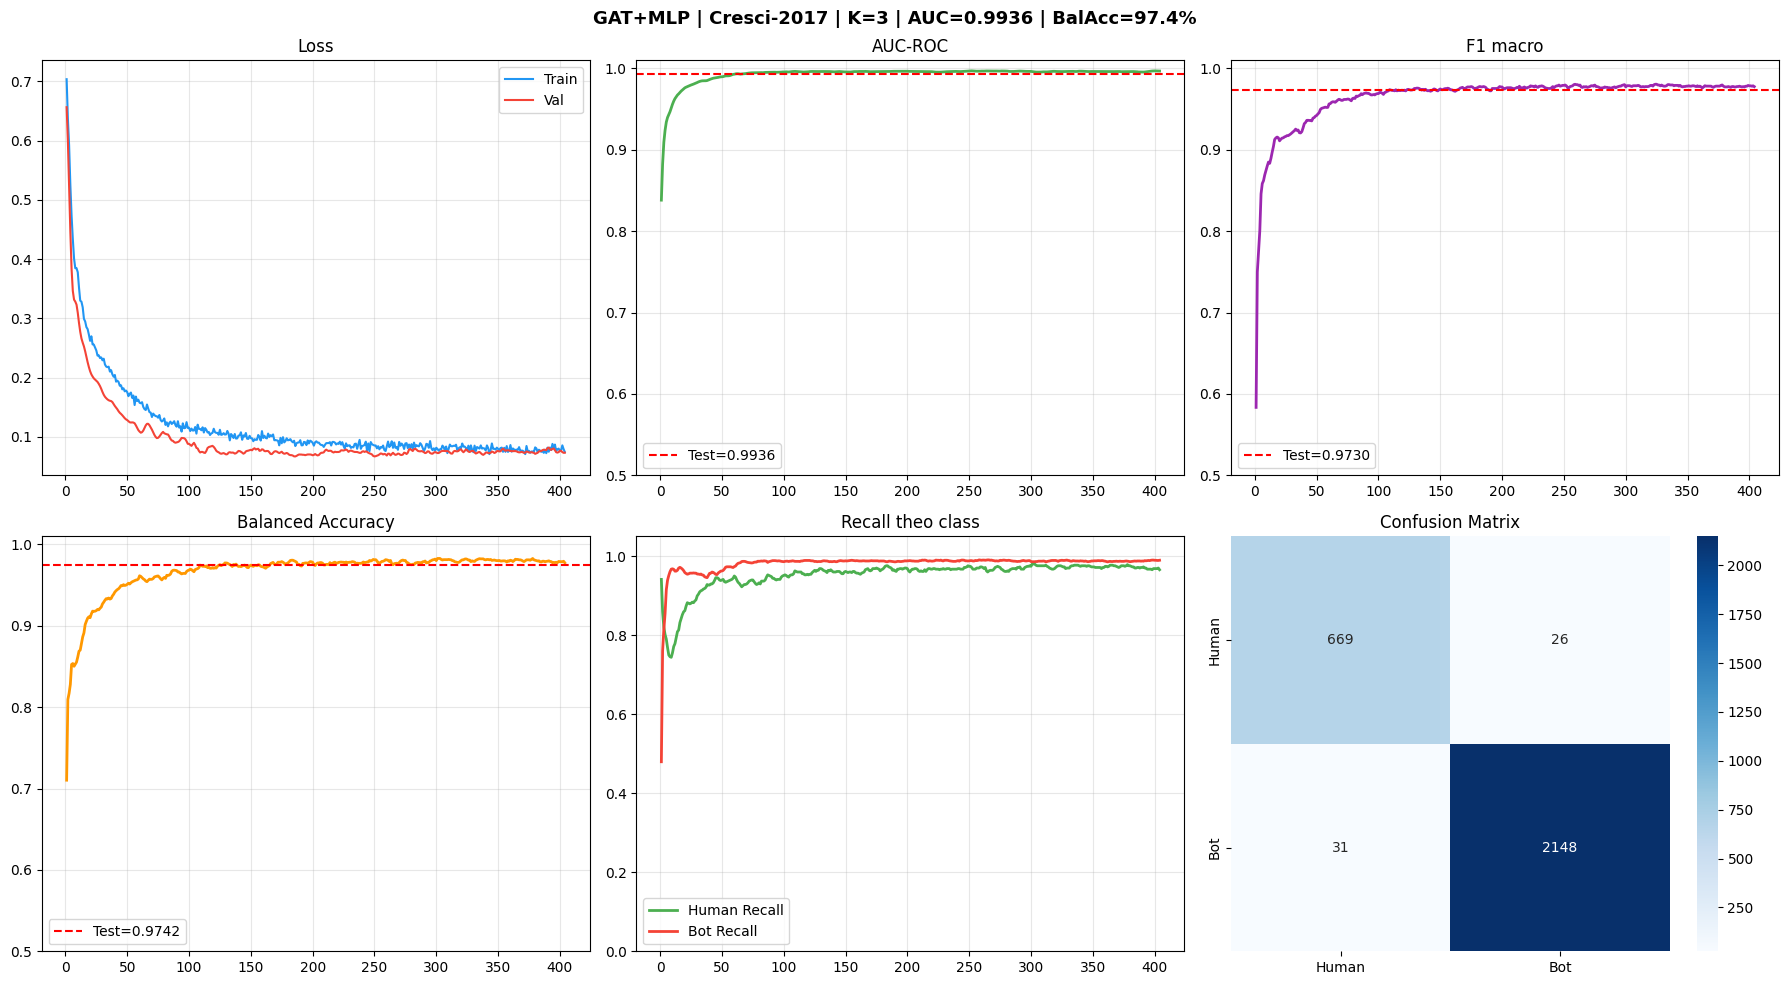

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'GAT+MLP | Cresci-2017 | K={K} | AUC={auc:.4f} | BalAcc={bal_acc*100:.1f}%',
             fontsize=13, fontweight='bold')

ep_ran = range(1, len(history['tl'])+1)

axes[0,0].plot(ep_ran, history['tl'], label='Train', color='#2196F3')
axes[0,0].plot(ep_ran, history['vl'], label='Val',   color='#F44336')
axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep_ran, history['vauc'], color='#4CAF50', linewidth=2)
axes[0,1].axhline(y=auc, color='red', linestyle='--', label=f'Test={auc:.4f}')
axes[0,1].set_title('AUC-ROC'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[0,1].set_ylim([0.5, 1.01])

axes[0,2].plot(ep_ran, history['vf1'], color='#9C27B0', linewidth=2)
axes[0,2].axhline(y=f1_mac, color='red', linestyle='--', label=f'Test={f1_mac:.4f}')
axes[0,2].set_title('F1 macro'); axes[0,2].legend(); axes[0,2].grid(alpha=0.3)
axes[0,2].set_ylim([0.5, 1.01])

axes[1,0].plot(ep_ran, history['vbal'], color='#FF9800', linewidth=2)
axes[1,0].axhline(y=bal_acc, color='red', linestyle='--', label=f'Test={bal_acc:.4f}')
axes[1,0].set_title('Balanced Accuracy'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)
axes[1,0].set_ylim([0.5, 1.01])

axes[1,1].plot(ep_ran, history['vrec_h'], color='#4CAF50', linewidth=2, label='Human Recall')
axes[1,1].plot(ep_ran, history['vrec_b'], color='#F44336', linewidth=2, label='Bot Recall')
axes[1,1].set_title('Recall theo class'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)
axes[1,1].set_ylim([0.0, 1.05])

cm = confusion_matrix(true, pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1,2],
            xticklabels=['Human','Bot'], yticklabels=['Human','Bot'], cmap='Blues')
axes[1,2].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('results_full.png', dpi=120, bbox_inches='tight')
plt.show()

In [20]:
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
    'K_optimal': K,
    'homophily': float(homophily),
    'metrics': {
        'accuracy': acc, 'auc': auc, 'f1_macro': f1_mac,
        'f1_weighted': f1_wei, 'balanced_accuracy': bal_acc
    }
}, 'gat_mlp_cresci2017_v5.pt')
print(f'✅ Saved | K={K} | Acc={acc*100:.2f}% | AUC={auc:.4f} | F1={f1_mac:.4f}')

✅ Saved | K=3 | Acc=98.02% | AUC=0.9936 | F1=0.9730


---
## 🌐 Bước 11: Cài Flask + pyngrok
### ⚠️ Lưu ý: chạy Bước 1–10 trước để model còn trong memory
- Lấy Ngrok Authtoken tại: https://dashboard.ngrok.com/get-started/your-authtoken
- Free plan: 1 tunnel / thời điểm, URL thay đổi mỗi lần restart Colab

In [21]:
!pip install flask pyngrok -q
from pyngrok import ngrok, conf
print('✅ Flask + pyngrok OK')

✅ Flask + pyngrok OK


---
## 🔑 Bước 12: Xác thực Ngrok
> Dán authtoken của bạn vào ô dưới. Set 1 lần/session là đủ.

In [22]:
# ── Dán authtoken của bạn vào đây ──────────────────────
NGROK_TOKEN = '3BskzzapehkdiqsOvsGx7bqmkgg_6nUYrCMb6NqppHakocfax'   # <<< THAY THẾ
# ─────────────────────────────────────────────────────────

ngrok.set_auth_token(NGROK_TOKEN)
print('✅ Ngrok auth OK')

✅ Ngrok auth OK


---
## 🧩 Bước 13: Hàm Inference (GAT cần graph context)

**Vấn đề:** `GATMLPHybrid` cần `edge_index` khi forward — không thể chỉ truyền feature vector.

**Giải pháp:** Giữ `X_scaled` (training nodes) làm *reference graph*. Khi node mới đến: KNN tìm K neighbors gần nhất → xây mini-graph → chạy model → lấy kết quả.

In [23]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.neighbors import NearestNeighbors

# ── Reference graph: toàn bộ X_scaled từ Bước 4 ──────────
# model, scaler, FEATURE_COLS, K, DEVICE đã có trong memory
X_REF = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
N_REF = X_REF.shape[0]

# Fit KNN 1 lần — tránh refit mỗi request
_knn_ref = NearestNeighbors(n_neighbors=K+1, metric='euclidean', n_jobs=-1)
_knn_ref.fit(X_scaled)
print(f'✅ Reference graph OK | {N_REF:,} nodes | K={K}')


def build_feature_vector(payload: dict) -> np.ndarray:
    """
    Nhận JSON payload từ client.
    Tính derived features → clip → StandardScaler → trả về (1, F).
    """
    age       = max(float(payload.get('account_age_days', 365)), 1)
    statuses  = float(payload.get('statuses_count', 0))
    followers = float(payload.get('followers_count', 0))
    friends   = float(payload.get('friends_count', 0))

    derived = {
        'account_age_days'     : age,
        'tweet_rate'           : min(statuses / age, 1e6),
        'follower_friend_ratio': min(followers / (friends + 1), 100),
        'name_length'          : float(payload.get('name_length', 0)),
        'desc_length'          : float(payload.get('desc_length', 0)),
    }
    merged = {**payload, **derived}

    row = np.array(
        [float(merged.get(c, 0)) for c in FEATURE_COLS],
        dtype=np.float32
    ).reshape(1, -1)

    return scaler.transform(row)   # (1, F) — KHÔNG re-fit scaler


@torch.no_grad()
def predict_single(payload: dict) -> dict:
    """
    Predict 1 node mới qua mini-graph.
    Trả về dict: label, confidence, prob_real, prob_spam.
    """
    x_new_np = build_feature_vector(payload)           # (1, F)

    # KNN: K+1 vì index 0 có thể là chính nó nếu nằm trong ref
    _, nbr_indices = _knn_ref.kneighbors(x_new_np)     # (1, K+1)
    nbr_idx = nbr_indices[0][:K]                       # lấy đúng K neighbors

    # Mini-graph: [K ref nodes] + [1 new node] → new node index = K
    context_np = np.vstack([X_scaled[nbr_idx], x_new_np])  # (K+1, F)
    context_x  = torch.tensor(context_np, dtype=torch.float32).to(DEVICE)
    new_idx    = K

    src = list(range(K)) + [new_idx] * K
    tgt = [new_idx] * K + list(range(K))
    mini_ei = torch.tensor([src, tgt], dtype=torch.long).to(DEVICE)

    model.eval()
    logits = model(context_x, mini_ei)                 # (K+1, 2)
    probs  = F.softmax(logits[new_idx], dim=0).cpu().numpy()

    label = 'spam' if probs[1] >= 0.5 else 'real'
    return {
        'label'         : label,
        'confidence'    : round(float(max(probs)), 4),
        'prob_real'     : round(float(probs[0]), 4),
        'prob_spam'     : round(float(probs[1]), 4),
        'feature_cols'  : FEATURE_COLS,
        'feature_vector': x_new_np[0].tolist()
    }


print('✅ predict_single() sẵn sàng')

# ── Smoke test ─────────────────────────────────────────────
_test = {
    'followers_count': 50000, 'friends_count': 10,
    'statuses_count' : 900000, 'listed_count': 2,
    'favourites_count': 0, 'verified': 0,
    'default_profile': 1, 'default_profile_image': 1,
    'geo_enabled': 0, 'account_age_days': 30,
    'name_length': 8, 'desc_length': 0
}
_r = predict_single(_test)
print(f'Smoke test → label={_r["label"]} | conf={_r["confidence"]} | prob_spam={_r["prob_spam"]}')

✅ Reference graph OK | 14,368 nodes | K=3
✅ predict_single() sẵn sàng
Smoke test → label=spam | conf=1.0 | prob_spam=1.0


---
## 🚀 Bước 14: Flask API + Ngrok Tunnel

| Method | Path | Mô tả |
|--------|------|---------|
| GET  | `/health` | Kiểm tra server còn sống |
| GET  | `/info`   | Metadata model (metrics, features) |
| POST | `/predict` | Predict **1 tài khoản** |
| POST | `/predict/batch` | Predict **nhiều tài khoản** (≤500) |

In [24]:
import threading, time
from flask import Flask, request, jsonify
from pyngrok import ngrok

app      = Flask(__name__)
MAX_BATCH = 500

MODEL_INFO = {
    'model'       : 'GAT+MLP Hybrid',
    'dataset'     : 'Cresci-2017',
    'feature_cols': FEATURE_COLS,
    'K_optimal'   : int(K),
    'homophily'   : round(float(homophily), 4),
    'metrics'     : {
        'accuracy'         : round(float(acc), 4),
        'auc_roc'          : round(float(auc), 4),
        'f1_macro'         : round(float(f1_mac), 4),
        'balanced_accuracy': round(float(bal_acc), 4),
    }
}


@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'device': str(DEVICE)}), 200


@app.route('/info', methods=['GET'])
def info():
    return jsonify(MODEL_INFO), 200


@app.route('/predict', methods=['POST'])
def predict():
    """
    Body JSON ví dụ:
    {
      "followers_count": 120, "friends_count": 45,
      "statuses_count": 300,  "listed_count": 5,
      "favourites_count": 100,"verified": 0,
      "default_profile": 1,   "default_profile_image": 0,
      "geo_enabled": 1,
      "account_age_days": 730,"name_length": 12,"desc_length": 60
    }
    """
    if not request.is_json:
        return jsonify({'error': 'Content-Type phải là application/json'}), 415

    payload = request.get_json(force=True)
    if not payload:
        return jsonify({'error': 'Body JSON rỗng'}), 400

    required_any = ['followers_count','friends_count','statuses_count','account_age_days']
    if not any(f in payload for f in required_any):
        return jsonify({'error': f'Thiếu field. Cần ít nhất 1 trong: {required_any}'}), 422

    try:
        result = predict_single(payload)
        return jsonify({'success': True, 'result': result}), 200
    except Exception as e:
        return jsonify({'success': False, 'error': str(e)}), 500


@app.route('/predict/batch', methods=['POST'])
def predict_batch():
    """Body: { "accounts": [{...}, {...}] }"""
    if not request.is_json:
        return jsonify({'error': 'Content-Type phải là application/json'}), 415

    body     = request.get_json(force=True)
    accounts = body.get('accounts', [])

    if not isinstance(accounts, list) or len(accounts) == 0:
        return jsonify({'error': '"accounts" phải là array không rỗng'}), 400
    if len(accounts) > MAX_BATCH:
        return jsonify({'error': f'Vượt giới hạn {MAX_BATCH} accounts/request'}), 413

    results, errors = [], []
    for i, acc in enumerate(accounts):
        try:
            res = predict_single(acc)
            results.append({'index': i, **res})
        except Exception as e:
            errors.append({'index': i, 'error': str(e)})
            results.append({'index': i, 'label': 'unknown',
                            'confidence': 0.0, 'error': str(e)})

    spam_count = sum(1 for r in results if r.get('label') == 'spam')
    return jsonify({
        'success'    : True,
        'total'      : len(accounts),
        'spam_count' : spam_count,
        'real_count' : len(accounts) - spam_count - len(errors),
        'error_count': len(errors),
        'results'    : results
    }), 200


# ── Khởi động Flask trong background thread ─────────────────
def run_flask():
    app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

flask_thread = threading.Thread(target=run_flask, daemon=True)
flask_thread.start()
time.sleep(2)   # chờ Flask lên

# ── Ngrok tunnel ─────────────────────────────────────────────
for t in ngrok.get_tunnels():          # đóng tunnel cũ nếu có
    ngrok.disconnect(t.public_url)

public_url = ngrok.connect(5000, bind_tls=True)
NGROK_URL  = public_url.public_url

print('=' * 62)
print('🚀  FLASK + NGROK ĐANG CHẠY')
print('=' * 62)
print(f'  Public URL   : {NGROK_URL}')
print(f'  Health check : {NGROK_URL}/health')
print(f'  Model info   : {NGROK_URL}/info')
print(f'  Predict      : POST {NGROK_URL}/predict')
print(f'  Batch predict: POST {NGROK_URL}/predict/batch')
print('=' * 62)
print()
print('📋 COPY URL này vào WinForms → UC05 Cấu hình Endpoint:')
print(f'   Ngrok Base URL → {NGROK_URL}')
print()
print('⚠️  URL thay đổi mỗi lần restart Colab (free plan).')
print('   Cập nhật lại trong UC05 sau mỗi lần restart.')

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


🚀  FLASK + NGROK ĐANG CHẠY
  Public URL   : https://repulsive-decussately-vashti.ngrok-free.dev
  Health check : https://repulsive-decussately-vashti.ngrok-free.dev/health
  Model info   : https://repulsive-decussately-vashti.ngrok-free.dev/info
  Predict      : POST https://repulsive-decussately-vashti.ngrok-free.dev/predict
  Batch predict: POST https://repulsive-decussately-vashti.ngrok-free.dev/predict/batch

📋 COPY URL này vào WinForms → UC05 Cấu hình Endpoint:
   Ngrok Base URL → https://repulsive-decussately-vashti.ngrok-free.dev

⚠️  URL thay đổi mỗi lần restart Colab (free plan).
   Cập nhật lại trong UC05 sau mỗi lần restart.


---
## 🧪 Bước 15: Test API ngay trong Colab
> Chạy cell này sau khi Bước 14 đã in ra URL để verify toàn bộ endpoints.

In [25]:
import requests

BASE    = NGROK_URL
HEADERS = {'Content-Type': 'application/json'}

print('─'*55)
print('TEST 1: GET /health')
r = requests.get(f'{BASE}/health', timeout=15)
print(f'  {r.status_code} | {r.json()}')

print()
print('TEST 2: POST /predict — profile bot điển hình')
bot_payload = {
    'followers_count': 85000, 'friends_count': 8,
    'statuses_count' : 950000, 'listed_count': 1,
    'favourites_count': 0, 'verified': 0,
    'default_profile': 1, 'default_profile_image': 1,
    'geo_enabled': 0, 'account_age_days': 25,
    'name_length': 7, 'desc_length': 0
}
r2  = requests.post(f'{BASE}/predict', json=bot_payload, headers=HEADERS, timeout=15)
res = r2.json()['result']
print(f'  {r2.status_code} | label={res["label"]} | conf={res["confidence"]} | prob_spam={res["prob_spam"]}')

print()
print('TEST 3: POST /predict — profile human điển hình')
human_payload = {
    'followers_count': 350, 'friends_count': 280,
    'statuses_count' : 1200, 'listed_count': 12,
    'favourites_count': 4500, 'verified': 0,
    'default_profile': 0, 'default_profile_image': 0,
    'geo_enabled': 1, 'account_age_days': 1800,
    'name_length': 14, 'desc_length': 85
}
r3  = requests.post(f'{BASE}/predict', json=human_payload, headers=HEADERS, timeout=15)
res3 = r3.json()['result']
print(f'  {r3.status_code} | label={res3["label"]} | conf={res3["confidence"]} | prob_real={res3["prob_real"]}')

print()
print('TEST 4: POST /predict/batch — 2 accounts')
r4   = requests.post(f'{BASE}/predict/batch',
                     json={'accounts': [bot_payload, human_payload]},
                     headers=HEADERS, timeout=30)
res4 = r4.json()
print(f'  {r4.status_code} | total={res4["total"]} spam={res4["spam_count"]} real={res4["real_count"]}')
for item in res4['results']:
    print(f'    [{item["index"]}] {item["label"]:4s} | conf={item["confidence"]}')

print()
print('✅ All tests passed — API sẵn sàng cho WinForms client!')

INFO:werkzeug:127.0.0.1 - - [22/Apr/2026 12:53:11] "GET /health HTTP/1.1" 200 -


───────────────────────────────────────────────────────
TEST 1: GET /health
  200 | {'device': 'cpu', 'status': 'ok'}

TEST 2: POST /predict — profile bot điển hình


INFO:werkzeug:127.0.0.1 - - [22/Apr/2026 12:53:11] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Apr/2026 12:53:11] "POST /predict HTTP/1.1" 200 -


  200 | label=spam | conf=1.0 | prob_spam=1.0

TEST 3: POST /predict — profile human điển hình
  200 | label=real | conf=0.9999 | prob_real=0.9999

TEST 4: POST /predict/batch — 2 accounts


INFO:werkzeug:127.0.0.1 - - [22/Apr/2026 12:53:11] "POST /predict/batch HTTP/1.1" 200 -


  200 | total=2 spam=1 real=1
    [0] spam | conf=1.0
    [1] real | conf=0.9999

✅ All tests passed — API sẵn sàng cho WinForms client!
